In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from itertools import groupby
import warnings

warnings.filterwarnings('ignore')

# 1. Транзакции

In [2]:
df_transaction = pd.read_csv('../data/train_transaction.csv')

df_transaction

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
def split_name(name):
    match = re.match(r"^(.*?)(\d+)$", name)
    if not match:
        return name, None
    return match.group(1), int(match.group(2))

In [4]:
print('Колонки в датасете:')
compressed = []
for prefix, group in groupby(df_transaction.columns, key=lambda name: split_name(name)[0]):
    names = list(group)
    if len(names) <= 2:
        for name in names:
            print(f"  {name}")
    else:
        numbers = [split_name(name)[1] for name in names]
        print(f"  {prefix}{numbers[0]}-{prefix}{numbers[-1]}")

Колонки в датасете:
  TransactionID
  isFraud
  TransactionDT
  TransactionAmt
  ProductCD
  card1-card6
  addr1
  addr2
  dist1
  dist2
  P_emaildomain
  R_emaildomain
  C1-C14
  D1-D15
  M1-M9
  V1-V339


## 1.1 TransactionID

Уникальный id транзакции

In [5]:
df_transaction.TransactionID.nunique()

590540

## 1.2. isFraud

Целевая переменная:
* 0 - легитимная транзакция
* 1 - фрод-транзакция

In [6]:
df_transaction.isFraud.value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [7]:
df_transaction.isFraud.value_counts(normalize=True)

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

Доля фрода в датасете - 3.5%.

* Доля фрода нестационарна во времени (агрегация по неделям):

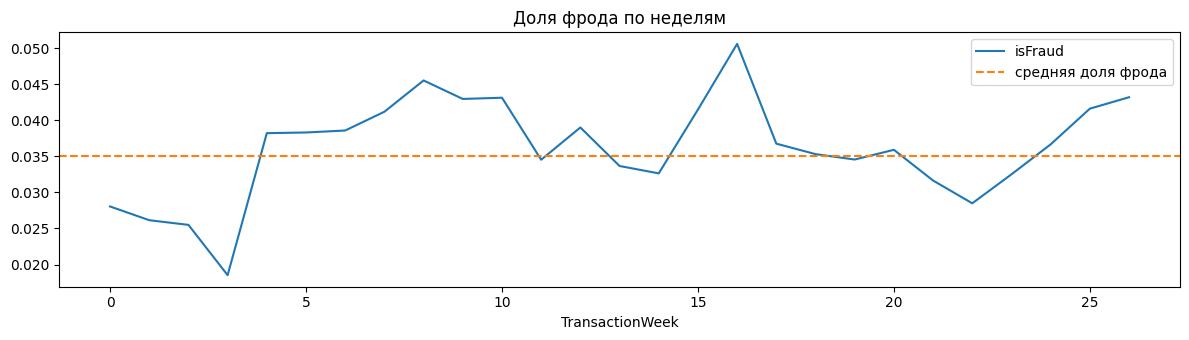

In [8]:
df_transaction['TransactionWeek'] = (df_transaction.TransactionDT // (86400 * 7)).astype(int)
weekly_fraud = df_transaction.groupby('TransactionWeek').isFraud.mean()

weekly_fraud.plot(figsize=(12, 3.5), title='Доля фрода по неделям')
plt.axhline(df_transaction.isFraud.mean(), color='C1', linestyle='--', label='средняя доля фрода')
plt.legend()
plt.tight_layout(); plt.show()

**Вывод:** Фрод приходит волнами: недельная доля колеблется в разы вокруг среднего уровня.

Следствия:
1. время корреляционно связано с таргетом, поэтому сырые временные признаки в модель подавать нельзя
2. валидация должна быть временной (подробнее — 02_feature_eda, §5)

## 1.3. TransactionDT

Время транзакции (дельта от референсной даты).

* Все транзакции отсортированы по времени:

In [9]:
(df_transaction.TransactionDT.diff()[1:] >= 0).all()

np.True_

* Минимальное значение `TransactionDT` - 86_400, что равно количеству секунд в сутках (60 * 60 * 24). Отсюда можно сделать вывод, что время в датасете измеряется в секундах.

In [10]:
df_transaction.TransactionDT.min()

np.int64(86400)

* Максимальное значение `TransactionDT` - 15_811_131. Таким образом, если предположение о секундах верное, в датасете собраны транзакции за 6 месяцев.

In [11]:
df_transaction.TransactionDT.max()

np.int64(15811131)

In [12]:
df_transaction.TransactionDT.max() / (60*60*24) / 30

np.float64(6.099973379629629)

* Повторяющихся значений `TransactionDT` мало ($\approx$ 17_000)

In [13]:
df_transaction.TransactionDT.value_counts()

TransactionDT
9474817     8
4397066     5
7236588     5
11576951    5
1544629     4
           ..
15811047    1
15811049    1
15811079    1
15811088    1
15811131    1
Name: count, Length: 573349, dtype: int64

* Объём транзакций по дням:

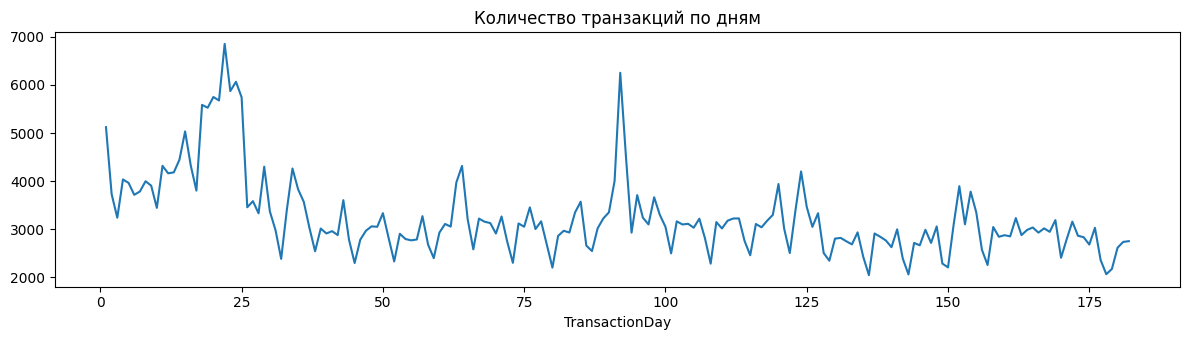

In [14]:
df_transaction['TransactionDay'] = df_transaction.TransactionDT // 86400

df_transaction.groupby('TransactionDay').size().plot(figsize=(12, 3.5), title='Количество транзакций по дням')
plt.tight_layout(); plt.show()

**Наблюдение:** Видна недельная 'пила' и глубокий провал в районе дней 24-25 — сообщество интерпретирует его как Рождество, откуда популярная оценка референсной даты T0 $\approx$ 1 декабря 2017. Для модели абсолютная привязка не нужна (см. 02_feature_eda, §2), но как проверка согласованности данных с календарем — полезное наблюдение.

## 1.4. TransactionAmt

Сумма транзакции в USD.

* Содержит 20_902 уникальных значения:

In [15]:
df_transaction.TransactionAmt.value_counts()

TransactionAmt
59.00      30582
117.00     28933
107.95     23954
57.95      23600
100.00     20362
           ...  
2286.27        1
1615.74        1
557.54         1
1659.95        1
400.78         1
Name: count, Length: 20902, dtype: int64

* Не содержит пропущенных значений:

In [16]:
df_transaction.TransactionAmt.value_counts().isna().sum()

np.int64(0)

* Рассмотрим наибольшее и наименьшее значение:

In [17]:
df_transaction.TransactionAmt.min(), df_transaction.TransactionAmt.max()

(np.float64(0.251), np.float64(31937.391))

* При таком разбросе значений гистограмма по всему диапазону не эффективна:

<Axes: >

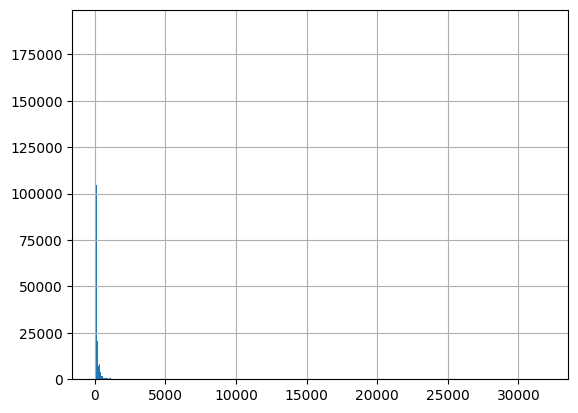

In [18]:
df_transaction.TransactionAmt.hist(bins=1000)

* Вычислим правый 95-квантиль (95% всех значений $\le$ данному):

In [19]:
quantile_value = df_transaction["TransactionAmt"].quantile(0.95)

quantile_value

np.float64(445.0)

* С учетом этих данных построим новую гистограмму, ограничив ось x значением 95-перцентиля:

(0.0, 445.0)

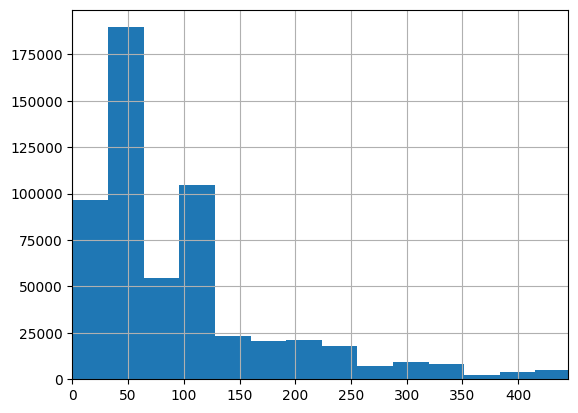

In [20]:
df_transaction.TransactionAmt.hist(bins=1_000)
plt.xlim(0, quantile_value)

* Сравним распределение в зависимости от статуса транзакции:

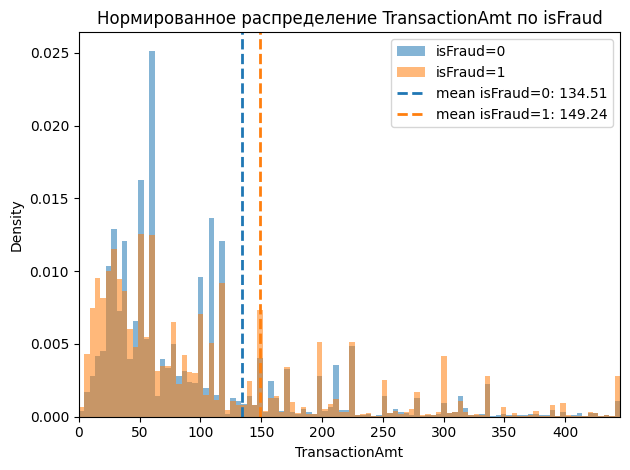

In [21]:
plt.hist(
    df_transaction.loc[df_transaction.isFraud == 0, "TransactionAmt"],
    bins=100,
    alpha=0.55,
    label="isFraud=0",
    range=(0, quantile_value),
    density=True
)
plt.hist(
    df_transaction.loc[df_transaction.isFraud == 1, "TransactionAmt"],
    bins=100,
    alpha=0.55,
    label="isFraud=1",
    range=(0, quantile_value),
    density=True
)

non_fraud_mean = df_transaction.loc[df_transaction.isFraud == 0, "TransactionAmt"].mean()
fraud_mean = df_transaction.loc[df_transaction.isFraud == 1, "TransactionAmt"].mean()
plt.axvline(non_fraud_mean, color="C0", linestyle="--", linewidth=2, label=f"mean isFraud=0: {non_fraud_mean:.2f}")
plt.axvline(fraud_mean, color="C1", linestyle="--", linewidth=2, label=f"mean isFraud=1: {fraud_mean:.2f}")

plt.xlim(0, quantile_value)
plt.xlabel("TransactionAmt")
plt.ylabel("Density")
plt.title("Нормированное распределение TransactionAmt по isFraud")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
percentiles = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95]

fraud_df = df_transaction.loc[df_transaction.isFraud == 1, "TransactionAmt"].quantile(percentiles)
non_fraud_df = df_transaction.loc[df_transaction.isFraud == 0, "TransactionAmt"].quantile(percentiles)

percentile_comparison = pd.DataFrame({
    "isFraud=0": non_fraud_df,
    "isFraud=1": fraud_df
})
percentile_comparison.index = [f"p{int(p * 100)}" for p in percentile_comparison.index]

percentile_comparison

,isFraud=0,isFraud=1
p10,26.310,18.936
p25,43.970,35.044
p50,68.500,75.000
p75,120.000,161.000
p90,267.112,335.000
p95,435.000,500.000


**Наблюдение:** Можно заметить, что мошенничество происходит на чуть более дорогих транзакциях.

## 1.5. ProductCD

Код продукта / услуги.

Категориальный признак.

* Содержит 5 уникальных значений, семантика которых неизвестна.

In [23]:
df_transaction.ProductCD.value_counts()

ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

* Не содержит пропущенных значений:

In [24]:
df_transaction.ProductCD.value_counts().isna().sum()

np.int64(0)

* Можно заметить, что самая большая доля мошенничества в классе C:

In [25]:
df_transaction.groupby('ProductCD').isFraud.agg(['count', 'mean']).sort_values('mean', ascending=False)

,count,mean
ProductCD,,
C,68519,0.116873
S,11628,0.058996
H,33024,0.047662
R,37699,0.037826
W,439670,0.020399


**Вывод:** Продукты сильно различаются и по объему, и по риску (C — $\approx$ 12% фрода против $\approx$ 2% у W). Это важный конфаундер: любые наблюдения о связи признака с фродом стоит перепроверять в разрезе ProductCD.

## 1.6. card1-card6

Официальной информации о семантике данных столбцов мало: *"payment card information, such as card type, card category, issue bank, country, etc."*

Категориальные признаки.

### card1

* Содержит $\approx$ 14_000 уникальных значений:

In [26]:
df_transaction.card1.value_counts()

card1
7919     14932
9500     14162
15885    10361
17188    10344
15066     7945
         ...  
7236         1
17972        1
13166        1
8767         1
18038        1
Name: count, Length: 13553, dtype: int64

* Не содержит пропущенных значений:

In [27]:
df_transaction.card1.isna().sum()

np.int64(0)

**Гипотеза:** `card1` — основной идентификатор карты (группа/BIN-уровня, см. 02_feature_eda, §3).

### card2

* Содержит всего 500 уникальных значений:

In [28]:
df_transaction.card2.value_counts()

card2
321.0    48935
111.0    45191
555.0    41995
490.0    38145
583.0    21803
         ...  
447.0       39
153.0       38
557.0       37
473.0       18
582.0       14
Name: count, Length: 500, dtype: int64

* Содержит пропуски в $\approx$ 1.5% записей:

In [29]:
df_transaction.card2.isna().sum()

np.int64(8933)

In [30]:
df_transaction.card2.isna().sum() / df_transaction.shape[0] * 100

np.float64(1.5126833068039423)

* Все значения трехзначные:

In [31]:
(~((df_transaction.card2.dropna() >= 100) & (df_transaction.card2.dropna() < 1000))).sum()

np.int64(0)

По малому количеству уникальных значений можно предположить, что `card2` содержит какую-то информацию о банке-эмитенте.

### card3

* Содержит всего 114 уникальных значений:

In [32]:
df_transaction.card3.value_counts()

card3
150.0    521287
185.0     56346
106.0      1571
144.0      1252
146.0      1252
          ...  
139.0         1
172.0         1
114.0         1
228.0         1
173.0         1
Name: count, Length: 114, dtype: int64

* Содержит незначительную долю пропусков:

In [33]:
df_transaction.card3.isna().sum()

np.int64(1565)

In [34]:
df_transaction.card3.isna().sum() / df_transaction.shape[0] * 100

np.float64(0.26501168422122123)

* Все значения трехзначные:

In [35]:
(~((df_transaction.card3.dropna() >= 100) & (df_transaction.card3.dropna() < 1000))).sum()

np.int64(0)

По малому количеству уникальных значений, можно предположить, что `card3` содержит какую-то информацию о банке-эмитенте.

### card4

* Данный признак определяет платежную систему:

In [36]:
df_transaction.card4.value_counts()

card4
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: count, dtype: int64

* Содержит незначительную долю пропусков:

In [37]:
df_transaction.card4.isna().sum()

np.int64(1577)

In [38]:
df_transaction.card4.isna().sum() / df_transaction.shape[0] * 100

np.float64(0.267043722694483)

* Доля фрода по платежным системам:

In [39]:
df_transaction.groupby('card4').isFraud.agg(['count', 'mean']).sort_values('mean', ascending=False)

,count,mean
card4,,
discover,6651,0.077282
visa,384767,0.034756
mastercard,189217,0.034331
american express,8328,0.028698


### card5

* Содержит всего 119 уникальных значений:

In [40]:
df_transaction.card5.value_counts()

card5
226.0    296546
224.0     81513
166.0     57140
102.0     29105
117.0     25941
          ...  
115.0         1
178.0         1
125.0         1
209.0         1
175.0         1
Name: count, Length: 119, dtype: int64

* Содержит незначительную долю пропусков:

In [41]:
df_transaction.card5.isna().sum()

np.int64(4259)

In [42]:
df_transaction.card5.isna().sum() / df_transaction.shape[0] * 100

np.float64(0.7212043214684865)

* Все значения трехзначные:

In [43]:
(~((df_transaction.card5.dropna() >= 100) & (df_transaction.card5.dropna() < 1000))).sum()

np.int64(0)

По малому количеству уникальных значений, можно предположить, что `card5` содержит какую-то информацию о банке-эмитенте.

### card6

* Данный признак определяет тип карты:

In [44]:
df_transaction.card6.value_counts()

card6
debit              439938
credit             148986
debit or credit        30
charge card            15
Name: count, dtype: int64

In [45]:
df_transaction.card6.isna().sum()

np.int64(1571)

* Содержит незначительную долю пропусков:

In [46]:
df_transaction.card6.isna().sum() / df_transaction.shape[0] * 100

np.float64(0.26602770345785215)

* Доля фрода по типу карты:

In [47]:
df_transaction.groupby('card6').isFraud.agg(['count', 'mean']).sort_values('mean', ascending=False)

,count,mean
card6,,
credit,148986,0.066785
debit,439938,0.024263
charge card,15,0.000000
debit or credit,30,0.000000


**Наблюдение:** Кредитные карты заметно фродовее дебетовых — ожидаемо для card-not-present мошенничества (выше лимиты, украденные данные чаще относятся к кредитным продуктам).

## 1.7. addr1, addr2

Категориальные признаки.

### addr1

* Регион плательщика

In [48]:
df_transaction.addr1.value_counts()

addr1
299.0    46335
325.0    42751
204.0    42020
264.0    39870
330.0    26287
         ...  
318.0        1
481.0        1
457.0        1
268.0        1
245.0        1
Name: count, Length: 332, dtype: int64

* Содержит пропуски в $\approx$ 11% записей:

In [49]:
df_transaction.addr1.isna().sum()

np.int64(65706)

In [50]:
df_transaction.addr1.isna().sum() / df_transaction.shape[0] * 100

np.float64(11.12642666034477)

### addr2

* Страна плательщика

In [51]:
df_transaction.addr2.value_counts()

addr2
87.0    520481
60.0      3084
96.0       638
32.0        91
65.0        82
         ...  
82.0         1
89.0         1
94.0         1
55.0         1
93.0         1
Name: count, Length: 74, dtype: int64

* Содержит пропуски в $\approx$ 11% записей:

In [52]:
df_transaction.addr2.isna().sum()

np.int64(65706)

In [53]:
df_transaction.addr2.isna().sum() / df_transaction.shape[0] * 100

np.float64(11.12642666034477)

* Одно значение покрывает подавляющее большинство записей (вероятно, США — платежи Vesta преимущественно американские):

In [54]:
df_transaction.addr2.value_counts(normalize=True).head(3)

addr2
87.0    0.991706
60.0    0.005876
96.0    0.001216
Name: proportion, dtype: float64

## 1.8. dist1, dist2

"Расстояние между платежным / почтовым адресами, IP-адресом, телефоном кодом и т.д.". Содержат много пропущенных значений.

### dist1

In [55]:
df_transaction.dist1.value_counts()

dist1
0.0       19824
1.0       18330
2.0       17028
4.0       13067
3.0       12808
          ...  
2658.0        1
1479.0        1
1838.0        1
4851.0        1
2042.0        1
Name: count, Length: 2651, dtype: int64

In [56]:
df_transaction.dist1.isna().sum()

np.int64(352271)

In [57]:
df_transaction.dist1.isna().sum() / df_transaction.shape[0] * 100

np.float64(59.6523520845328)

### dist2

In [58]:
df_transaction.dist2.value_counts()

dist2
7.0       5687
0.0       3519
1.0       1374
9.0        742
4.0        659
          ... 
1954.0       1
1585.0       1
3007.0       1
1172.0       1
2296.0       1
Name: count, Length: 1751, dtype: int64

In [59]:
df_transaction.dist2.isna().sum()

np.int64(552913)

In [60]:
df_transaction.dist2.isna().sum() / df_transaction.shape[0] * 100

np.float64(93.62837403054831)

## 1.9. P_emaildomain

email-домен плательщика.

Категориальный признак.

In [61]:
df_transaction.P_emaildomain.value_counts()

P_emaildomain
gmail.com           228355
yahoo.com           100934
hotmail.com          45250
anonymous.com        36998
aol.com              28289
comcast.net           7888
icloud.com            6267
outlook.com           5096
msn.com               4092
att.net               4033
live.com              3041
sbcglobal.net         2970
verizon.net           2705
ymail.com             2396
bellsouth.net         1909
yahoo.com.mx          1543
me.com                1522
cox.net               1393
optonline.net         1011
charter.net            816
live.com.mx            749
rocketmail.com         664
mail.com               559
earthlink.net          514
gmail                  496
outlook.es             438
mac.com                436
juno.com               322
aim.com                315
hotmail.es             305
roadrunner.com         305
windstream.net         305
hotmail.fr             295
frontier.com           280
embarqmail.com         260
web.de                 240
netzero.com   

In [62]:
df_transaction.P_emaildomain.nunique()

59

* Содержит пропуски в $\approx$ 16% записей:

In [63]:
df_transaction.P_emaildomain.isna().sum()

np.int64(94456)

In [64]:
df_transaction.P_emaildomain.isna().sum() / df_transaction.shape[0] * 100

np.float64(15.99485216920107)

* Доля фрода по доменам (домены с $\ge$ 1000 транзакций, топ-10 по риску):

In [65]:
(df_transaction.groupby('P_emaildomain').isFraud.agg(['count', 'mean'])
    .query('count >= 1000')
    .sort_values('mean', ascending=False)
    .head(10))

,count,mean
P_emaildomain,,
outlook.com,5096,0.094584
hotmail.com,45250,0.052950
gmail.com,228355,0.043542
icloud.com,6267,0.031434
comcast.net,7888,0.031187
bellsouth.net,1909,0.027763
live.com,3041,0.027622
anonymous.com,36998,0.023217
yahoo.com,100934,0.022757


**Вывод:** внутри массовых доменов риск различается в разы: outlook.com ($\approx$ 9.5%) против yahoo.com ($\approx$ 2.3%) при базовом уровне $\approx$ 3.5%. Показателен контраст внутри одной экосистемы: hotmail.com (легаси-ящики) — 5.3%, outlook.com (домен свежесозданных аккаунтов Microsoft) — 9.5%: риск связан со 'свежестью' популяции ящиков домена, а фродовые ящики — свежие. Отдельная ловушка: anonymous.com ($\approx$ 37_000 транзакций, риск *ниже* базового) — судя по объему, плейсхолдер маскировки от организаторов, а не реальный почтовый сервис; трактовать его как 'анонимную почту' нельзя.

* Без порога по count топ по риску занимают редкие домены:

In [66]:
(df_transaction.groupby('P_emaildomain').isFraud.agg(['count', 'mean'])
    .sort_values('mean', ascending=False)
    .head(10))

,count,mean
P_emaildomain,,
protonmail.com,76,0.407895
mail.com,559,0.189624
outlook.es,438,0.130137
aim.com,315,0.126984
outlook.com,5096,0.094584
hotmail.es,305,0.065574
live.com.mx,749,0.054740
hotmail.com,45250,0.052950
gmail.com,228355,0.043542


**Вывод:** лидеры риска — privacy-ориентированные сервисы со свободной анонимной регистрацией: protonmail.com — 40.8% фрода, mail.com — 19.0% (против базовых 3.5%). Механизм: фродеру нужна свежая почта под каждую партию краденых карт — быстро, без телефона и следов; такие сервисы собирают непропорциональную долю одноразовых ящиков.

Стоит отдельно отметить, что, несмотря на малые объемы (76 и 559 транзакций) и широкие доверительные интервалы, эти данные показывают статистически подавляющее отличие от базового уровня, хотя и не фиксируют точную величину риска.

Практическое следствие: сигнал редких доменов надежнее передавать модели через 'группу провайдера' и 'суффикс домена' (реализация — 02_feature_eda, §5.1), а не через сырые категории с десятками наблюдений; один провайдер к тому же представлен множеством вариантов написания (gmail.com / gmail и т.п.).

## 1.10. R_emaildomain

email-домен получателя (для транзакций, в которых не требуется получатель, - *NaN*).

Категориальный признак.

In [67]:
df_transaction.R_emaildomain.value_counts()

R_emaildomain
gmail.com           57147
hotmail.com         27509
anonymous.com       20529
yahoo.com           11842
aol.com              3701
outlook.com          2507
comcast.net          1812
yahoo.com.mx         1508
icloud.com           1398
msn.com               852
live.com              762
live.com.mx           754
verizon.net           620
me.com                556
sbcglobal.net         552
cox.net               459
outlook.es            433
att.net               430
bellsouth.net         422
hotmail.fr            293
hotmail.es            292
web.de                237
mac.com               218
prodigy.net.mx        207
ymail.com             207
optonline.net         187
gmx.de                147
yahoo.fr              137
charter.net           127
mail.com              122
hotmail.co.uk         105
gmail                  95
earthlink.net          79
yahoo.de               75
rocketmail.com         69
embarqmail.com         68
scranton.edu           63
yahoo.es               5

* Содержит пропуски в $\approx$ 77% записей:

In [68]:
df_transaction.R_emaildomain.isna().sum()

np.int64(453249)

In [69]:
df_transaction.R_emaildomain.isna().sum() / df_transaction.shape[0] * 100

np.float64(76.75161716395164)

## 1.11. C1-C14

* Cчетчики
* Точная семантика неизвестна
* Количество сущностей (адреса, телефоны, email и т.д.), ассоциированных с плательщиком / получателем

In [70]:
df_transaction[[f'C{i}' for i in range(1, 15)]].sample(10, random_state=42)

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14
470624,3.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,0.0,2.0,2.0
565820,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,7.0,2.0
284083,1.0,1.0,0.0,0.0,2.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,1.0
239689,2.0,3.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
281855,10.0,14.0,0.0,0.0,11.0,8.0,0.0,0.0,6.0,0.0,10.0,0.0,43.0,9.0
413908,6.0,4.0,0.0,0.0,0.0,2.0,0.0,0.0,4.0,0.0,3.0,0.0,13.0,5.0
413692,106.0,105.0,0.0,0.0,102.0,92.0,0.0,0.0,69.0,0.0,82.0,0.0,407.0,80.0
474182,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
370788,4.0,5.0,0.0,2.0,0.0,2.0,2.0,2.0,0.0,3.0,1.0,1.0,1.0,1.0
28757,2.0,2.0,0.0,0.0,0.0,8.0,0.0,0.0,4.0,0.0,2.0,0.0,12.0,2.0


In [71]:
df_transaction[[f'C{i}' for i in range(1, 15)]].isna().sum()

C1     0
C2     0
C3     0
C4     0
C5     0
C6     0
C7     0
C8     0
C9     0
C10    0
C11    0
C12    0
C13    0
C14    0
dtype: int64

* Распределения с очень тяжелыми хвостами (медиана — единицы, максимумы — тысячи):

In [72]:
c_cols = [f'C{i}' for i in range(1, 15)]
df_transaction[c_cols].agg(['median', 'max']).T

,median,max
C1,1.0,4685.0
C2,1.0,5691.0
C3,0.0,26.0
C4,0.0,2253.0
C5,0.0,349.0
C6,1.0,2253.0
C7,0.0,2255.0
C8,0.0,3331.0
C9,1.0,210.0
C10,0.0,3257.0


* Признаки сильно взаимно коррелируют:

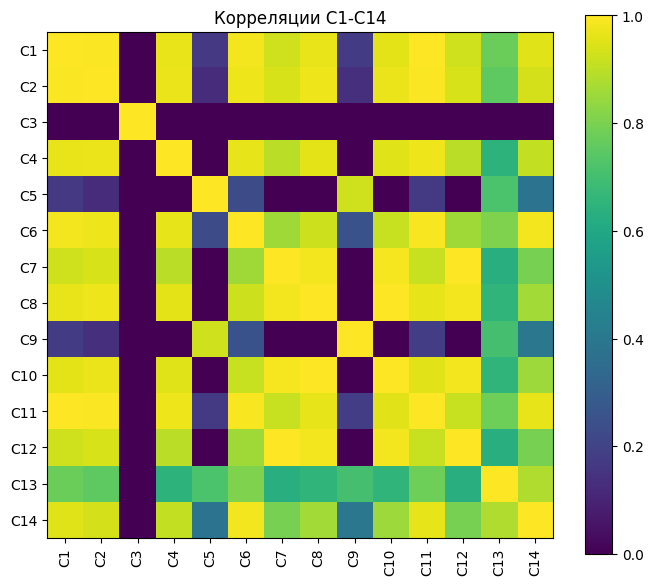

In [73]:
c_corr = df_transaction[c_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(c_corr, vmin=0, vmax=1, cmap='viridis')
ax.set_xticks(range(len(c_cols)), c_cols, rotation=90)
ax.set_yticks(range(len(c_cols)), c_cols)
fig.colorbar(im)
ax.set_title('Корреляции C1-C14')
plt.tight_layout(); plt.show()

**Вывод:** Избыточность семейства аналогична V-признакам. При этом C-признаки предпосчитаны организатором и включаются в baseline как есть, одинаково во всех ветках эксперимента (см. 02_feature_eda, §7).

## 1.12. D1-D15

* Временные дельты
* Точная семантика неизвестна
* Например: дельта от предыдущей транзакции до текущей

In [74]:
df_transaction[[f'D{i}' for i in range(1, 16)]].sample(10, random_state=42)

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15
470624,0.0,NaN,NaN,145.0,0.0,NaN,NaN,NaN,NaN,145.0,0.0,NaN,NaN,NaN,145.0
565820,122.0,122.0,5.0,347.0,5.0,NaN,NaN,NaN,NaN,347.0,122.0,NaN,NaN,NaN,347.0
284083,32.0,32.0,22.0,22.0,22.0,NaN,NaN,NaN,NaN,33.0,33.0,NaN,NaN,NaN,33.0
239689,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0.0
281855,549.0,549.0,16.0,549.0,16.0,NaN,NaN,NaN,NaN,446.0,NaN,NaN,NaN,NaN,549.0
413908,0.0,NaN,NaN,358.0,57.0,NaN,NaN,NaN,NaN,481.0,0.0,NaN,NaN,NaN,0.0
413692,330.0,330.0,181.0,341.0,52.0,NaN,NaN,NaN,NaN,209.0,303.0,NaN,NaN,NaN,341.0
474182,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
370788,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.791666,0.791666,0.0,NaN,0.0,0.0,0.0,150.0
28757,40.0,40.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,284.0,0.0,NaN,NaN,NaN,284.0


In [75]:
df_transaction[[f'D{i}' for i in range(1, 16)]].isna().sum()

D1       1269
D2     280797
D3     262878
D4     168922
D5     309841
D6     517353
D7     551623
D8     515614
D9     515614
D10     76022
D11    279287
D12    525823
D13    528588
D14    528353
D15     89113
dtype: int64

In [76]:
df_transaction[[f'D{i}' for i in range(1, 16)]].isna().sum() / df_transaction.shape[0] * 100

D1      0.214888
D2     47.549192
D3     44.514851
D4     28.604667
D5     52.467403
D6     87.606767
D7     93.409930
D8     87.312290
D9     87.312290
D10    12.873302
D11    47.293494
D12    89.041047
D13    89.509263
D14    89.469469
D15    15.090087
dtype: float64

## 1.13. M1-M9

* Проверка соответствий (чаще всего - бинарная)
* Точная семантика неизвестна
* Например: совпадают ли имена / платежные адреса
* Категориальные признаки.

In [77]:
df_transaction[[f'M{i}' for i in range(1, 10)]].sample(10, random_state=42)

,M1,M2,M3,M4,M5,M6,M7,M8,M9
470624,T,T,F,M0,F,T,F,F,T
565820,T,T,T,M0,F,T,T,T,T
284083,T,T,T,NaN,NaN,F,NaN,NaN,NaN
239689,NaN,NaN,NaN,M2,NaN,NaN,NaN,NaN,NaN
281855,NaN,NaN,NaN,NaN,NaN,T,NaN,NaN,NaN
413908,T,T,T,M0,F,F,F,F,T
413692,T,T,T,NaN,NaN,NaN,F,F,T
474182,T,T,T,M0,F,T,F,F,T
370788,NaN,NaN,NaN,M2,NaN,NaN,NaN,NaN,NaN
28757,T,F,F,M1,F,F,NaN,NaN,NaN


In [78]:
df_transaction[[f'M{i}' for i in range(1, 10)]].isna().sum()

M1    271100
M2    271100
M3    271100
M4    281444
M5    350482
M6    169360
M7    346265
M8    346252
M9    346252
dtype: int64

In [79]:
df_transaction[[f'M{i}' for i in range(1, 10)]].isna().sum() / df_transaction.shape[0] * 100

M1    45.907136
M2    45.907136
M3    45.907136
M4    47.658753
M5    59.349409
M6    28.678836
M7    58.635317
M8    58.633115
M9    58.633115
dtype: float64

## 1.14. V1-V339

* Признаки, разработанные в Vesta
* Точная семантика неизвестна
* Содержат ранги, счетчики и другие взаимоотношения между сущностями
* Не упоминаются в качестве категориальных признаков

In [80]:
df_transaction[[f'V{i}' for i in range(1, 340)]].sample(10, random_state=42)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
470624,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
565820,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
284083,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
239689,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
281855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
413908,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
413692,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
474182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
370788,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28757,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


* Пропуски имеют блочную структуру — доля NaN меняется 'ступенями' по группам соседних колонок:

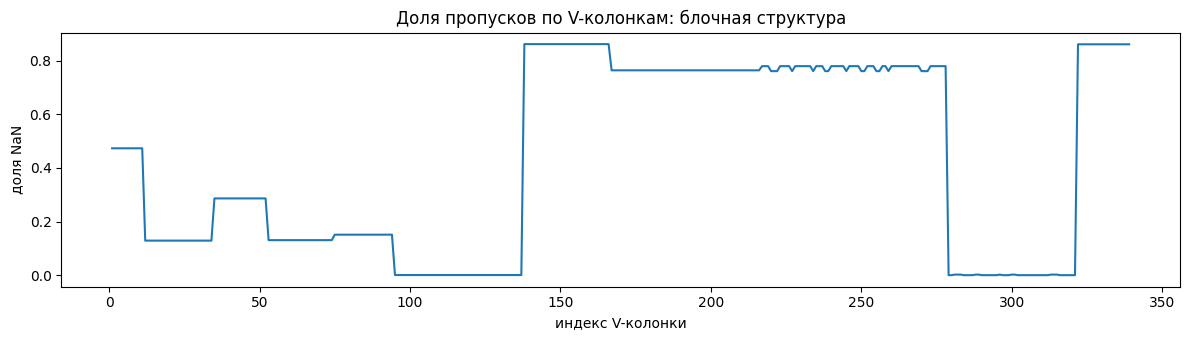

In [81]:
v_cols = [f'V{i}' for i in range(1, 340)]
v_nan_share = df_transaction[v_cols].isna().mean()

plt.figure(figsize=(12, 3.5))
plt.plot(range(1, 340), v_nan_share.values)
plt.xlabel('индекс V-колонки')
plt.ylabel('доля NaN')
plt.title('Доля пропусков по V-колонкам: блочная структура')
plt.tight_layout(); plt.show()

**Вывод:** Каждая 'ступень' — группа колонок, посчитанная от одного источника (вся группа заполнена или пуста одновременно). На этой структуре рассматривалась дедупликация семейства; по результатам прогона она отклонена — все V-признаки идут в baseline как есть (см. 02_feature_eda, §4).

# 2. Identity

In [82]:
df_identity = pd.read_csv('../data/train_identity.csv')

df_identity

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144228,3577521,-15.0,145955.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 66.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,F3111 Build/33.3.A.1.97
144229,3577526,-5.0,172059.0,NaN,NaN,1.0,-5.0,NaN,NaN,NaN,...,chrome 55.0 for android,32.0,855x480,match_status:2,T,F,T,F,mobile,A574BL Build/NMF26F
144230,3577529,-20.0,632381.0,NaN,NaN,-1.0,-36.0,NaN,NaN,NaN,...,chrome 65.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,Moto E (4) Plus Build/NMA26.42-152
144231,3577531,-5.0,55528.0,0.0,0.0,0.0,-7.0,NaN,NaN,0.0,...,chrome 66.0,24.0,2560x1600,match_status:2,T,F,T,F,desktop,MacOS


In [83]:
compressed = []
for prefix, group in groupby(df_identity.columns, key=lambda name: split_name(name)[0]):
    names = list(group)
    if len(names) <= 2:
        for name in names:
            print(name)
    else:
        numbers = [split_name(name)[1] for name in names]
        print(f"{prefix}{numbers[0]}-{prefix}{numbers[-1]}")

TransactionID
id_1-id_38
DeviceType
DeviceInfo


Таблица содержит данные о сетевом подключении (IP-адрес, интернет-провайдер, прокси-сервер и т.д.) и цифровой сигнатуре (User-Agent / браузер / ОС версия и т.д.), связанные с транзакциями. Данные собраны Vesta и партнёрами.

## 2.1. TransactionID

Уникальный id транзакции

In [84]:
df_identity.TransactionID.nunique()

144233

Всего $\approx$ 24% транзакций содержат характеристики, отраженные в данной таблице:

In [85]:
df_identity.TransactionID.isin(df_transaction.TransactionID).all()

np.True_

In [86]:
df_identity.shape[0] / df_transaction.shape[0] * 100

24.42391709283029

## 2.2. id_01-id_38

### id_01-id_11

* Числовые признаки
* Рейтинг устройства, IP и т.д.
* Поведенческие паттерны (например, количество попыток входа)

In [87]:
df_identity[[f'id_{i:02d}' for i in range(1, 12)]].sample(10, random_state=42)

,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11
46485,-5.0,52720.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0
138945,-10.0,1106.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,100.0
53023,-20.0,214795.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,100.0
4422,-5.0,42350.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0
8939,-5.0,309254.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,100.0
54532,-5.0,58787.0,0.0,0.0,0.0,-22.0,NaN,NaN,0.0,0.0,100.0
94960,-5.0,89652.0,NaN,NaN,2.0,0.0,NaN,NaN,NaN,NaN,100.0
15110,-90.0,34630.0,0.0,0.0,0.0,-15.0,14.0,-59.0,0.0,0.0,100.0
57011,-5.0,113766.0,NaN,NaN,0.0,-25.0,NaN,NaN,NaN,NaN,100.0
96862,0.0,167997.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,100.0


In [88]:
df_identity[[f'id_{i:02d}' for i in range(1, 12)]].isna().sum()

id_01         0
id_02      3361
id_03     77909
id_04     77909
id_05      7368
id_06      7368
id_07    139078
id_08    139078
id_09     69307
id_10     69307
id_11      3255
dtype: int64

In [89]:
df_identity[[f'id_{i:02d}' for i in range(1, 12)]].isna().sum() / df_identity.shape[0] * 100

id_01     0.000000
id_02     2.330257
id_03    54.016071
id_04    54.016071
id_05     5.108401
id_06     5.108401
id_07    96.425922
id_08    96.425922
id_09    48.052110
id_10    48.052110
id_11     2.256765
dtype: float64

### id_12-id_38

* Категориальные признаки

In [90]:
df_identity[[f'id_{i}' for i in range(12, 27)]].sample(10, random_state=42)

,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26
46485,NotFound,52.0,-300.0,Found,Found,166.0,NaN,312.0,597.0,NaN,NaN,NaN,NaN,NaN,NaN
138945,Found,27.0,NaN,Found,Found,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53023,NotFound,52.0,NaN,New,NotFound,225.0,15.0,427.0,541.0,NaN,NaN,NaN,NaN,NaN,NaN
4422,NotFound,52.0,-300.0,Found,Found,166.0,NaN,410.0,597.0,NaN,NaN,NaN,NaN,NaN,NaN
8939,NotFound,52.0,NaN,New,NotFound,225.0,NaN,266.0,325.0,NaN,NaN,NaN,NaN,NaN,NaN
54532,NotFound,52.0,-480.0,Found,Found,166.0,NaN,591.0,222.0,NaN,NaN,NaN,NaN,NaN,NaN
94960,NotFound,52.0,-300.0,New,NotFound,166.0,NaN,100.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN
15110,NotFound,52.0,-480.0,Found,Found,166.0,12.0,337.0,222.0,596.0,14.0,IP_PROXY:HIDDEN,16.0,501.0,161.0
57011,NotFound,49.0,NaN,New,NotFound,225.0,NaN,176.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN
96862,NotFound,NaN,-420.0,New,NotFound,166.0,13.0,492.0,204.0,NaN,NaN,NaN,NaN,NaN,NaN


In [91]:
df_identity[[f'id_{i}' for i in range(27, 39)]].sample(10, random_state=42)

,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38
46485,NaN,Found,Found,Windows 10,chrome 63.0,24.0,2560x1440,match_status:2,T,F,T,F
138945,NaN,Found,Found,NaN,NaN,NaN,NaN,match_status:2,T,F,T,F
53023,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T
4422,NaN,Found,Found,Windows 10,edge 15.0,24.0,1280x768,match_status:2,T,F,T,T
8939,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T
54532,NaN,Found,Found,Windows 7,chrome 63.0,24.0,1600x900,match_status:2,T,F,T,F
94960,NaN,New,NotFound,Windows 10,chrome 64.0,24.0,1920x1080,match_status:2,T,F,T,T
15110,Found,Found,Found,Windows 7,chrome 63.0,24.0,1920x1080,match_status:2,T,F,T,T
57011,NaN,New,NotFound,NaN,chrome 46.0 for android,NaN,NaN,NaN,F,F,T,F
96862,NaN,New,NotFound,iOS 11.2.6,mobile safari generic,32.0,2048x1536,match_status:2,T,F,T,T


id_30 - ОС:

In [92]:
df_identity.id_30.value_counts()

id_30
Windows 10          21155
Windows 7           13110
iOS 11.2.1           3722
iOS 11.1.2           3699
Android 7.0          2871
                    ...  
func                   10
iOS 11.4.0              5
Mac OS X 10_13_5        4
Windows                 3
iOS 11.4.1              1
Name: count, Length: 75, dtype: int64

id_31 - версия браузера:

In [93]:
df_identity.id_31.value_counts()

id_31
chrome 63.0                22000
mobile safari 11.0         13423
mobile safari generic      11474
ie 11.0 for desktop         9030
safari generic              8195
                           ...  
Cherry                         1
android                        1
firefox mobile 61.0            1
chrome 69.0                    1
chrome 67.0 for android        1
Name: count, Length: 130, dtype: int64

**Наблюдение:** Значения версионированы (chrome 63.0, chrome 69.0, ...) — сырая колонка дробит один браузер на десятки категорий, причем со временем появляются новые версии, которых нет в train. Производный признак 'семейство браузера' включен в baseline (реализация — 02_feature_eda, §5.3; семейство устройства для DeviceInfo — §5.2).

id_33 - разрешение экрана:

In [94]:
df_identity.id_33.value_counts()

id_33
1920x1080    16874
1366x768      8605
1334x750      6447
2208x1242     4900
1440x900      4384
             ...  
2160x1081        1
1920x1279        1
1596x710         1
1496x844         1
1280x900         1
Name: count, Length: 260, dtype: int64

## 2.3. DeviceType

Тип устройства:

In [95]:
df_identity.DeviceType.value_counts()

DeviceType
desktop    85165
mobile     55645
Name: count, dtype: int64

* Содержит незначительную долю пропусков:

In [96]:
df_identity.DeviceType.isna().sum()

np.int64(3423)

In [97]:
df_identity.DeviceType.isna().sum() / df_identity.shape[0] * 100

np.float64(2.373243293837055)

* Доля фрода по типу устройства (isFraud присоединяем из таблицы транзакций):

In [98]:
device_fraud = df_identity[['TransactionID', 'DeviceType']].merge(
    df_transaction[['TransactionID', 'isFraud']], on='TransactionID'
)
device_fraud.groupby('DeviceType').isFraud.agg(['count', 'mean'])

,count,mean
DeviceType,,
desktop,85165,0.065215
mobile,55645,0.101662


## 2.4. DeviceInfo

Информация об устройстве (может содержат как название ОС, так и конкретную модель устройства):

In [99]:
df_identity.DeviceInfo.value_counts()

DeviceInfo
Windows                        47722
iOS Device                     19782
MacOS                          12573
Trident/7.0                     7440
rv:11.0                         1901
                               ...  
G8142                              1
G630-U251                          1
LG-K212                            1
LDN-LX3 Build/HUAWEILDN-LX3        1
Z955A                              1
Name: count, Length: 1786, dtype: int64

In [100]:
df_identity.DeviceInfo.isna().sum()

np.int64(25567)

* Содержит пропуски в $\approx$ 18% записей:

In [101]:
df_identity.DeviceInfo.isna().sum() / df_identity.shape[0] * 100

np.float64(17.726179168428864)